In [1]:
import numpy as np
import pandas as pd
import matplotlib
import openpyxl

In [3]:
! pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]




[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import pandas as pd

reg_sheets = pd.read_excel("RegistrationName.xlsx", sheet_name=None)
score_sheets = pd.read_excel("StudentScores.xlsx", sheet_name=None)

for name, df in reg_sheets.items():
    print(name)
    print(df.sample(5))

for name, df in score_sheets.items():
    print(name)
    print(df.sample(5))

reg_df = reg_sheets["NameList"]
hw_df = score_sheets["Homework"]
quiz1_df = score_sheets["Quiz1"]
quiz2_df = score_sheets["Quiz2"]
mt_df = score_sheets["MidtermExam"]
fn_df = score_sheets["FinalExam"]

NameList
    No     SID          Name                Email  Section
37  38  140270    Mr.Lh  Pfh  Pfh.Lh.14@ubu.ac.th        2
32  33  140119    Mr.Gt  Bet  Bet.Gt.14@ubu.ac.th        2
46  47  140531  Miss.Ub  Ufb  Ufb.Ub.14@ubu.ac.th        2
30  31  140063    Mr.Em  Ukm  Ukm.Em.14@ubu.ac.th        2
36  37  140247    Mr.Kn  Vln  Vln.Kn.14@ubu.ac.th        2
Homework
                  Email     SID Last Name First Name  HW1_10  HW2_5  HW3_15  \
56  Tea.Na.14@ubu.ac.th  140320       Tea         Na     5.0    2.0      15   
12  Xap.Op.14@ubu.ac.th  140335       Xap         Op     7.0    2.0       4   
25  Wxf.Hf.14@ubu.ac.th  140267       Wxf         Hf    10.0    5.0      13   
17  Wmo.Jo.14@ubu.ac.th  140201       Wmo         Jo     NaN    1.0      14   
11  Svk.Dk.14@ubu.ac.th  140780       Svk         Dk     9.0    5.0      12   

   HW4_10  
56      9  
12      4  
25      2  
17      6  
11      3  
Quiz1
                 Timestamp     SID     Name Quiz1_10
24 2020-10-02 11:26:01

In [15]:
print("จำนวนแถวซ้ำ:", hw_df.duplicated().sum())   # ผลจริง = 3 แถวซ้ำ
hw_df = hw_df.drop_duplicates()
print("จำนวนแถวหลังลบ:", len(hw_df))              # เหลือ 60 แถว

จำนวนแถวซ้ำ: 3
จำนวนแถวหลังลบ: 60


In [16]:
all_sheets = {
    "NameList": reg_df, "Homework": hw_df, "Quiz1": quiz1_df,
    "Quiz2": quiz2_df, "MidtermExam": mt_df, "FinalExam": fn_df
}

# 3.1
for name, df in all_sheets.items():
    print(name)
    print(df.isnull().sum() / len(df) * 100)

for name, df in all_sheets.items():
    df.fillna(0, inplace=True)

# 3.2
for name, df in all_sheets.items():
    print(name)
    print(df.info())

# พบว่า HW4_10 กับ Quiz1_10 ถูกอ่านเป็น object เพราะมีค่า "-" และ "none" ปนอยู่
hw_df["HW4_10"] = pd.to_numeric(hw_df["HW4_10"], errors="coerce").fillna(0)
quiz1_df["Quiz1_10"] = pd.to_numeric(quiz1_df["Quiz1_10"], errors="coerce").fillna(0)

NameList
No         0.0
SID        0.0
Name       0.0
Email      0.0
Section    0.0
dtype: float64
Homework
Email         0.000000
SID           0.000000
Last Name     0.000000
First Name    0.000000
HW1_10        6.666667
HW2_5         5.000000
HW3_15        0.000000
HW4_10        0.000000
dtype: float64
Quiz1
Timestamp    0.000000
SID          0.000000
Name         0.000000
Quiz1_10     3.333333
dtype: float64
Quiz2
Timestamp    0.000000
SID          0.000000
Name         0.000000
Quiz2_10     6.666667
dtype: float64
MidtermExam
Email      0.0
SID        0.0
Name       0.0
Section    0.0
MT_25      0.0
dtype: float64
FinalExam
Email      0.0
SID        0.0
Name       0.0
Section    0.0
FN_25      0.0
dtype: float64
NameList
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   No       60 non-null     int64
 1   SID      60 non-null     int64
 2   Name     60 non-null    

In [18]:
merged = reg_df.merge(hw_df[["SID","HW1_10","HW2_5","HW3_15","HW4_10"]], on="SID")
merged = merged.merge(quiz1_df[["SID","Quiz1_10"]], on="SID")
merged = merged.merge(quiz2_df[["SID","Quiz2_10"]], on="SID")
merged = merged.merge(mt_df[["SID","MT_25"]], on="SID")
merged = merged.merge(fn_df[["SID","FN_25"]], on="SID")

merged = merged[["SID","Name","Email","Section","HW1_10","HW2_5","HW3_15",
                  "HW4_10","Quiz1_10","Quiz2_10","MT_25","FN_25"]]
merged = merged.set_index("SID")
merged.head()

,Name,Email,Section,HW1_10,HW2_5,HW3_15,HW4_10,Quiz1_10,Quiz2_10,MT_25,FN_25
SID,,,,,,,,,,,
140018,Mr.Af Ndf,Ndf.Af.14@ubu.ac.th,1,10.0,3.0,11,8.0,4.0,7.0,17,13
140021,Miss.By Pqy,Pqy.By.14@ubu.ac.th,1,8.0,2.0,11,2.0,10.0,0.0,12,18
140098,Miss.Ck Sik,Sik.Ck.14@ubu.ac.th,1,10.0,4.0,13,9.0,6.0,6.0,15,24
140137,Mr.Dr Zjr,Zjr.Dr.14@ubu.ac.th,1,10.0,2.0,8,8.0,10.0,5.0,10,13
140153,Miss.Eg Xyg,Xyg.Eg.14@ubu.ac.th,1,4.0,2.0,8,3.0,4.0,5.0,15,23


In [19]:
merged["Total HW"] = merged["HW1_10"] + merged["HW2_5"] + merged["HW3_15"] + merged["HW4_10"]
merged["Total QZ"] = merged["Quiz1_10"] + merged["Quiz2_10"]
merged["Total Scores"] = merged["Total HW"] + merged["Total QZ"] + merged["MT_25"] + merged["FN_25"]

merged = merged.sort_values(by="Total Scores", ascending=False)
print(merged.head(10))

                Name                Email  Section  HW1_10  HW2_5  HW3_15  \
SID                                                                         
140531  Miss.Ub  Ufb  Ufb.Ub.14@ubu.ac.th        2    10.0    5.0      13   
140449  Miss.Rv  Dgv  Dgv.Rv.14@ubu.ac.th        2    10.0    4.0       7   
140098  Miss.Ck  Sik  Sik.Ck.14@ubu.ac.th        1    10.0    4.0      13   
140717  Miss.Wo  Wzo  Wzo.Wo.14@ubu.ac.th        1    10.0    5.0      14   
140494    Mr.Nu  Cfu  Cfu.Nu.14@ubu.ac.th        1    10.0    4.0      14   
140568  Miss.Xi  Qgi  Qgi.Xi.14@ubu.ac.th        2    10.0    3.0      12   
140403    Mr.Kl  Tjl  Tjl.Kl.14@ubu.ac.th        1     6.0    3.0      15   
140557  Miss.Wd  Uvd  Uvd.Wd.14@ubu.ac.th        2    10.0    3.0      12   
140586    Mr.Qw  Now  Now.Qw.14@ubu.ac.th        1     6.0    4.0      15   
140870    Mr.Hx  Opx  Opx.Hx.14@ubu.ac.th        2     5.0    4.0       8   

        HW4_10  Quiz1_10  Quiz2_10  MT_25  FN_25  Total HW  Total QZ  \
SID

In [20]:
# 6.1
df_60up = merged.loc[merged["Total Scores"] >= 60]
df_60up = df_60up.sort_values(by="Total Scores")

# 6.2
df_top5 = df_60up.iloc[0:5][["Name", "Email", "Section", "Total Scores"]]
print(df_top5)

                Name                Email  Section  Total Scores
SID                                                             
140335    Mr.Op  Xap  Xap.Op.14@ubu.ac.th        2          60.5
140270    Mr.Lh  Pfh  Pfh.Lh.14@ubu.ac.th        2          60.5
140043    Mr.Cr  Zcr  Zcr.Cr.14@ubu.ac.th        2          61.0
140063    Mr.Em  Ukm  Ukm.Em.14@ubu.ac.th        2          61.5
140742  Miss.Ci  Qti  Qti.Ci.14@ubu.ac.th        2          61.5


In [21]:
def grading(score):
    if score >= 80:
        return "A"
    elif score >= 70:
        return "B"
    elif score >= 60:
        return "C"
    elif score >= 50:
        return "D"
    else:
        return "F"

grade_list = []
for score in merged["Total Scores"]:
    grade_list.append(grading(score))

merged["Grading"] = grade_list
merged = merged.sort_values(by="Grading")
print(merged.head(10))

                Name                Email  Section  HW1_10  HW2_5  HW3_15  \
SID                                                                         
140531  Miss.Ub  Ufb  Ufb.Ub.14@ubu.ac.th        2    10.0    5.0      13   
140658    Mr.Zb  Stb  Stb.Zb.14@ubu.ac.th        2    10.0    4.0      15   
140397    Mr.Qm  Uxm  Uxm.Qm.14@ubu.ac.th        2    10.0    4.0      13   
140586    Mr.Qw  Now  Now.Qw.14@ubu.ac.th        1     6.0    4.0      15   
140557  Miss.Wd  Uvd  Uvd.Wd.14@ubu.ac.th        2    10.0    3.0      12   
140403    Mr.Kl  Tjl  Tjl.Kl.14@ubu.ac.th        1     6.0    3.0      15   
140870    Mr.Hx  Opx  Opx.Hx.14@ubu.ac.th        2     5.0    4.0       8   
140494    Mr.Nu  Cfu  Cfu.Nu.14@ubu.ac.th        1    10.0    4.0      14   
140717  Miss.Wo  Wzo  Wzo.Wo.14@ubu.ac.th        1    10.0    5.0      14   
140098  Miss.Ck  Sik  Sik.Ck.14@ubu.ac.th        1    10.0    4.0      13   

        HW4_10  Quiz1_10  Quiz2_10  MT_25  FN_25  Total HW  Total QZ  \
SID

In [24]:
print("Mean:", merged["Total Scores"].mean())   # 70.34
print("Std :", merged["Total Scores"].std())    # 10.12
print("Min :", merged["Total Scores"].min())    # 45.5
print("Max :", merged["Total Scores"].max())    # 99.0

# หรือจะใช้ describe ก็ได้
merged.describe()

Mean: 70.34166666666667
Std : 10.122341319344589
Min : 45.5
Max : 99.0


,Section,HW1_10,HW2_5,HW3_15,HW4_10,Quiz1_10,Quiz2_10,MT_25,FN_25,Total HW,Total QZ,Total Scores
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,1.533333,7.266667,3.033333,9.666667,5.816667,6.900000,5.208333,16.233333,16.216667,25.783333,12.108333,70.341667
std,0.503098,3.063545,1.275143,3.535134,2.561062,2.627753,1.848709,4.130772,4.270878,7.078475,3.235256,10.122341
min,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,10.000000,8.000000,11.000000,4.500000,45.500000
25%,1.000000,6.000000,2.000000,7.000000,4.000000,5.750000,4.500000,12.750000,13.000000,20.000000,10.375000,63.375000
50%,2.000000,8.000000,3.000000,10.000000,6.000000,7.000000,5.500000,17.000000,16.000000,27.000000,12.500000,68.750000
75%,2.000000,10.000000,4.000000,12.000000,8.000000,9.000000,6.500000,20.250000,18.250000,31.250000,14.500000,78.250000
max,2.000000,10.000000,5.000000,15.000000,10.000000,10.000000,8.500000,22.000000,24.000000,38.000000,17.500000,99.000000


In [25]:
merged.to_excel("Student_Grading.xlsx", sheet_name="Final Grading")

Grading
A    12
B    15
C    26
D     6
F     1
Name: count, dtype: int64


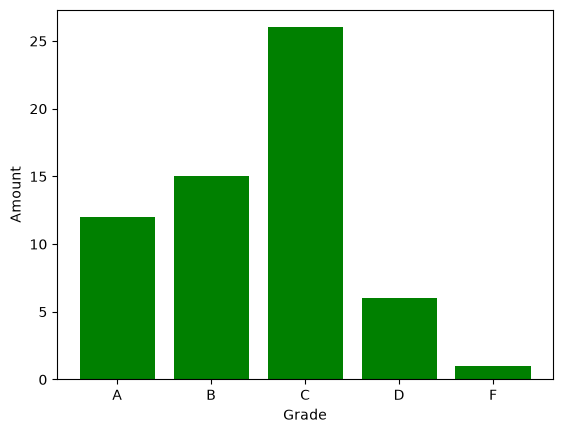

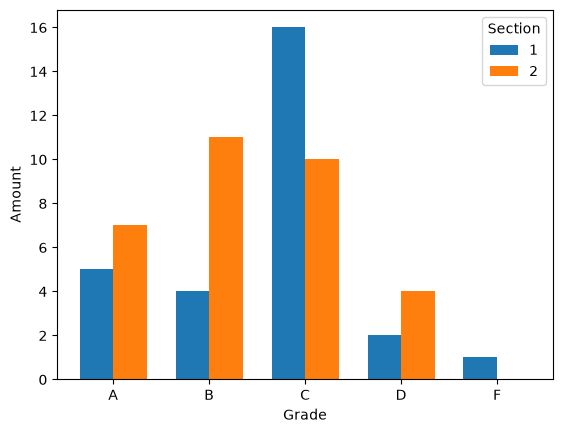

In [26]:
import matplotlib.pyplot as plt

grade_order = ["A","B","C","D","F"]

# 10.1
grade_count = merged["Grading"].value_counts().reindex(grade_order, fill_value=0)
print(grade_count)   # A=12, B=15, C=26, D=6, F=1

plt.bar(grade_count.index, grade_count.values, color="green")
plt.xlabel("Grade"); plt.ylabel("Amount")
plt.show()

# 10.2
sec1 = merged[merged["Section"]==1]["Grading"].value_counts().reindex(grade_order, fill_value=0)
sec2 = merged[merged["Section"]==2]["Grading"].value_counts().reindex(grade_order, fill_value=0)

x = range(5)
width = 0.35
plt.bar([i-width/2 for i in x], sec1.values, width, label="1")
plt.bar([i+width/2 for i in x], sec2.values, width, label="2")
plt.xticks(list(x), grade_order)
plt.xlabel("Grade"); plt.ylabel("Amount")
plt.legend(title="Section")
plt.show()